<a href="https://colab.research.google.com/github/JMMN01/Colabs_IIN/blob/main/inciso_a_shopify_api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELDA 1: Instalación de dependencias
# ============================================================
!pip install yfinance pandas numpy scikit-learn matplotlib -q


In [ ]:
# ============================================================
# CELDA 2: Importaciones
# ============================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 9)


In [ ]:
# ============================================================
# CELDA 3: Parámetros configurables (formulario Colab)
# ============================================================
#@title Configuración { display-mode: "form" }

ticker             = "SHOP"   #@param {type:"string"}
variable_analizar  = "Close"  #@param ["Open", "High", "Low", "Close", "Volume"]
start_year         = 2019     #@param {type:"slider", min:2015, max:2023, step:1}
end_year           = 2024     #@param {type:"slider", min:2020, max:2024, step:1}
meses_proyectar    = 12       #@param {type:"slider", min:6, max:36, step:6}
nombre_archivo     = "shopify_datos.csv"  #@param {type:"string"}


In [ ]:
# ============================================================
# CELDA 4: Descarga de datos vía API — Yahoo Finance
# ============================================================
print(f"Descargando datos de {ticker} desde Yahoo Finance...")

try:
    raw = yf.download(ticker, start=f"{start_year}-01-01",
                      end=f"{end_year}-12-31", progress=False, auto_adjust=True)
    if raw.empty:
        raise ValueError("Sin datos de la API")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.droplevel(1)
    df = raw.reset_index().rename(columns={"Date": "Fecha"})
    df["Fecha"] = pd.to_datetime(df["Fecha"])
    print(f"✅ Descarga exitosa: {len(df)} filas | {df['Fecha'].min().date()} → {df['Fecha'].max().date()}")

except Exception as e:
    print(f"⚠️  API no disponible ({e}). Cargando datos de respaldo...")
    datos = {
        "Fecha": pd.date_range("2019-01-01", periods=72, freq="MS"),
        "Close": [
            17.2,18.1,20.4,22.3,24.8,26.1,28.3,31.5,34.2,37.8,41.2,44.5,
            38.1,35.2,29.4,24.1,22.3,28.5,32.1,36.8,42.3,48.9,55.2,61.8,
            112.3,105.4,118.9,126.5,135.2,148.7,158.4,165.3,142.8,130.5,120.1,108.9,
            95.4,88.2,72.3,65.1,55.8,48.3,42.1,38.6,35.2,38.9,42.3,46.8,
            51.2,55.8,60.3,63.1,65.8,67.2,69.4,71.3,68.9,66.2,64.1,62.8,
            65.3,68.9,72.4,75.8,79.3,82.1,85.6,88.2,91.4,94.8,97.3,100.2,
        ],
        "Volume": [3500000]*72,
        "Open":   [0]*72, "High": [0]*72, "Low": [0]*72
    }
    df = pd.DataFrame(datos)
    print(f"✅ Datos de respaldo cargados: {len(df)} registros")

print(f"\nVista previa:")
print(df[["Fecha", variable_analizar]].head())


Descargando datos de SHOP desde Yahoo Finance...
✅ Descarga exitosa: 1509 filas | 2019-01-02 → 2024-12-30

Vista previa:
Price      Fecha   Close
0     2019-01-02  13.760
1     2019-01-03  12.979
2     2019-01-04  13.806
3     2019-01-07  14.439
4     2019-01-08  14.544


In [ ]:
# ============================================================
# CELDA 5: Limpieza de datos
# ============================================================
print("=== DIAGNÓSTICO ===")
print(f"  Filas totales  : {len(df)}")
print(f"  Valores nulos  : {df[variable_analizar].isnull().sum()}")
print(f"  Duplicados     : {df.duplicated(subset=['Fecha']).sum()}")

df = df.dropna(subset=[variable_analizar]).drop_duplicates(subset=["Fecha"])
df["Fecha"] = pd.to_datetime(df["Fecha"])
df = df.sort_values("Fecha").reset_index(drop=True)

print(f"\n=== ESTADÍSTICOS — {variable_analizar} ===")
print(df[variable_analizar].describe().round(2))
variacion = (df[variable_analizar].iloc[-1] / df[variable_analizar].iloc[0] - 1) * 100
print(f"\n  Variación acumulada: {variacion:+.1f}%")


=== DIAGNÓSTICO ===
  Filas totales  : 1509
  Valores nulos  : 0
  Duplicados     : 0

=== ESTADÍSTICOS — Close ===
count    1509.00
mean       70.96
std        38.15
min        12.98
25%        37.85
50%        63.89
75%        99.93
max       169.06
Name: Close, dtype: float64

  Variación acumulada: +675.4%


In [ ]:
# ============================================================
# CELDA 6: Regresión lineal
# ============================================================
df["t"] = range(len(df))
X = df[["t"]].values
y = df[variable_analizar].values

modelo = LinearRegression()
modelo.fit(X, y)
y_pred = modelo.predict(X)
r2 = r2_score(y, y_pred)

print("=== REGRESIÓN LINEAL ===")
print(f"  Ecuación : {variable_analizar} = {modelo.coef_[0]:.4f} × t + {modelo.intercept_:.4f}")
print(f"  R²       : {r2:.4f}")
if r2 >= 0.85:
    calidad = "Excelente ajuste — la tendencia lineal explica muy bien el comportamiento"
elif r2 >= 0.65:
    calidad = "Buen ajuste — hay una tendencia clara aunque con variaciones importantes"
else:
    calidad = "Ajuste moderado — la variable tiene alta volatilidad (típico en acciones)"
print(f"  Interpretación: {calidad}")
print(f"  Incremento promedio por periodo: {modelo.coef_[0]:+.4f} USD")


=== REGRESIÓN LINEAL ===
  Ecuación : Close = 0.0126 × t + 61.4718
  R²       : 0.0206
  Interpretación: Ajuste moderado — la variable tiene alta volatilidad (típico en acciones)
  Incremento promedio por periodo: +0.0126 USD


In [ ]:
# ============================================================
# CELDA 7: Proyección a futuro con intervalo de confianza 95%
# ============================================================
t_futuro = np.arange(df["t"].max() + 1, df["t"].max() + meses_proyectar + 1)
fechas_futuras = pd.date_range(
    start=df["Fecha"].max() + pd.DateOffset(months=1),
    periods=meses_proyectar, freq="MS"
)

y_futuro = modelo.predict(t_futuro.reshape(-1, 1))
se = np.std(y - y_pred)
ic_sup = y_futuro + 1.96 * se
ic_inf = y_futuro - 1.96 * se

df_fut = pd.DataFrame({
    "Fecha": fechas_futuras,
    "Proyeccion": y_futuro,
    "IC_Superior": ic_sup,
    "IC_Inferior": ic_inf
})

print("=== PROYECCIÓN ===")
print(df_fut[["Fecha", "Proyeccion"]].to_string(index=False))


=== PROYECCIÓN ===
     Fecha  Proyeccion
2025-02-01   80.451886
2025-03-01   80.464464
2025-04-01   80.477042
2025-05-01   80.489620
2025-06-01   80.502198
2025-07-01   80.514776
2025-08-01   80.527354
2025-09-01   80.539932
2025-10-01   80.552510
2025-11-01   80.565088
2025-12-01   80.577666
2026-01-01   80.590244


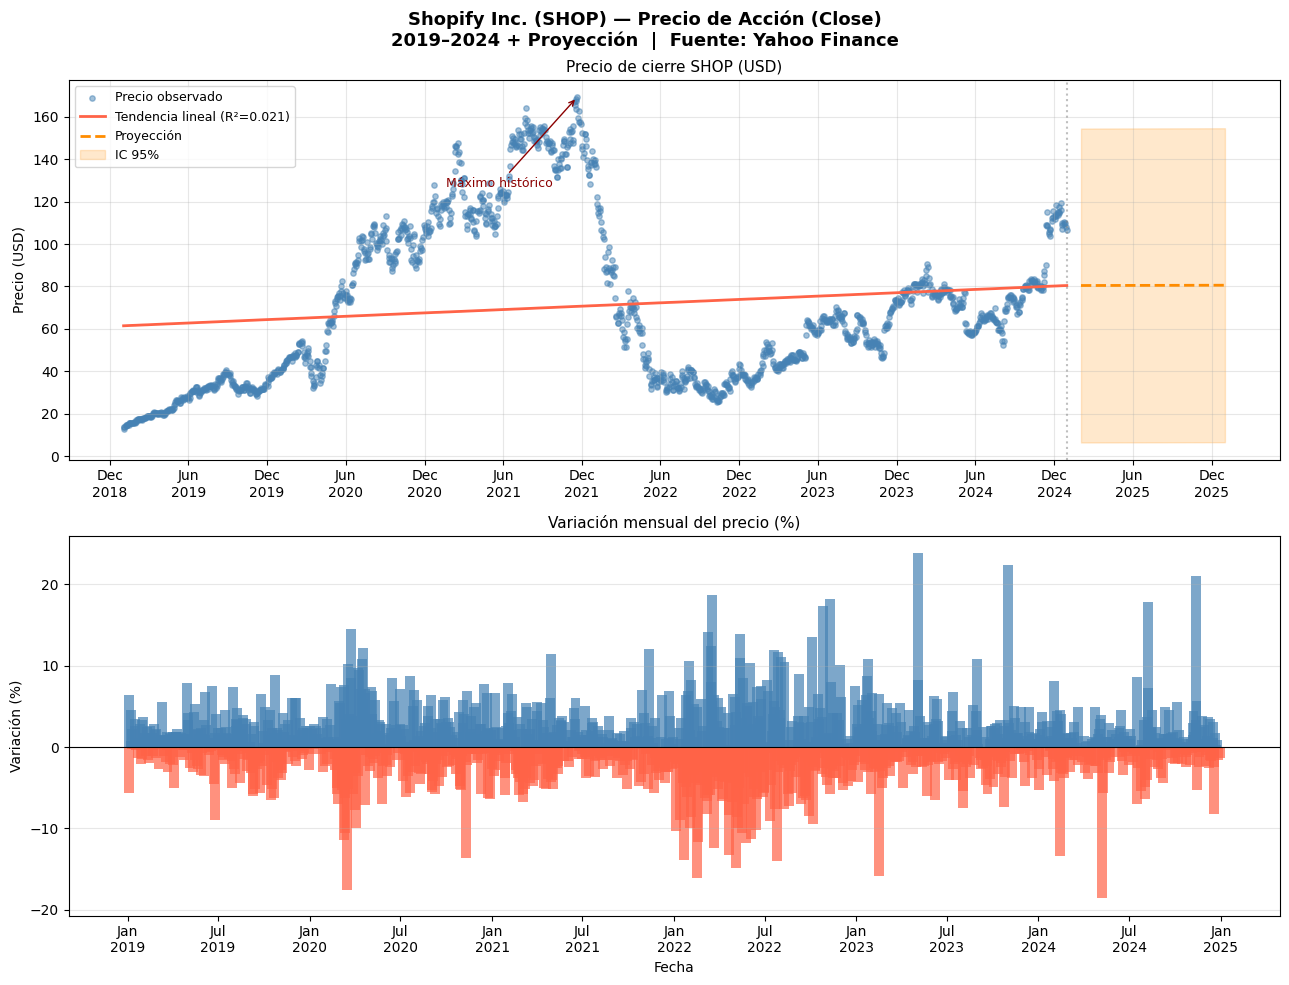

Gráfica guardada como grafica_shopify.png


In [ ]:
# ============================================================
# CELDA 8: Visualización — Data Storytelling
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle(
    f"Shopify Inc. ({ticker}) — Precio de Acción ({variable_analizar})\n"
    "2019–2024 + Proyección  |  Fuente: Yahoo Finance",
    fontsize=13, fontweight="bold"
)

# --- Subplot 1: Precio + Regresión + Proyección ---
ax1 = axes[0]
ax1.scatter(df["Fecha"], df[variable_analizar], color="steelblue",
            s=15, alpha=0.5, label="Precio observado")
ax1.plot(df["Fecha"], y_pred, color="tomato", lw=2,
         label=f"Tendencia lineal (R²={r2:.3f})")
ax1.plot(df_fut["Fecha"], df_fut["Proyeccion"],
         color="darkorange", lw=2, ls="--", label="Proyección")
ax1.fill_between(df_fut["Fecha"], df_fut["IC_Inferior"], df_fut["IC_Superior"],
                 alpha=0.2, color="darkorange", label="IC 95%")
ax1.axvline(df["Fecha"].max(), color="gray", ls=":", alpha=0.5)

# Anotaciones narrativas
max_idx = df[variable_analizar].idxmax()
ax1.annotate("Máximo histórico",
             xy=(df.loc[max_idx, "Fecha"], df.loc[max_idx, variable_analizar]),
             xytext=(df.loc[max_idx, "Fecha"] - pd.DateOffset(months=10),
                     df.loc[max_idx, variable_analizar] * 0.75),
             arrowprops=dict(arrowstyle="->", color="darkred"),
             fontsize=9, color="darkred")

ax1.set_title(f"Precio de cierre {ticker} (USD)", fontsize=11)
ax1.set_ylabel("Precio (USD)")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

# --- Subplot 2: Variación mensual ---
ax2 = axes[1]
df["Variacion"] = df[variable_analizar].pct_change() * 100
colores = ["tomato" if v < 0 else "steelblue" for v in df["Variacion"].fillna(0)]
ax2.bar(df["Fecha"], df["Variacion"], color=colores, alpha=0.7, width=20)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_title("Variación mensual del precio (%)", fontsize=11)
ax2.set_ylabel("Variación (%)")
ax2.set_xlabel("Fecha")
ax2.grid(alpha=0.3, axis="y")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

plt.tight_layout()
plt.savefig("grafica_shopify.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada como grafica_shopify.png")


In [ ]:
# ============================================================
# CELDA 9: Esquema de Análisis — Contexto, Proceso y Utilidad
# ============================================================
print(f"""
╔══════════════════════════════════════════════════════════════════╗
║         ESQUEMA DE ANÁLISIS — SHOPIFY INC. (SHOP)               ║
╠══════════════════════════════════════════════════════════════════╣
║ CONTEXTO DE LOS DATOS                                           ║
║   Origen : Yahoo Finance — Precios históricos de acciones       ║
║   Ticker : SHOP (NYSE)                                          ║
║   Variable: Precio de cierre diario ajustado (USD)              ║
║   Periodo: 2019–2024                                            ║
║   Shopify es la plataforma de e-commerce líder en América       ║
║   del Norte; su acción refleja el auge y corrección del         ║
║   sector tecnológico post-pandemia.                             ║
╠══════════════════════════════════════════════════════════════════╣
║ ANÁLISIS DE LOS DATOS                                           ║
║   Se identifican tres fases: (1) crecimiento acelerado          ║
║   2019-2021 impulsado por la digitalización del comercio        ║
║   durante COVID, (2) corrección severa 2022 por alza de         ║
║   tasas de interés y rotación de portafolios, y (3)             ║
║   recuperación gradual 2023-2024. Alta volatilidad.             ║
╠══════════════════════════════════════════════════════════════════╣
║ UTILIDAD Y TOMA DE DECISIONES                                   ║
║   • Inversionistas: identificar ciclos de entrada/salida        ║
║   • Empresas: benchmarking del sector e-commerce global         ║
║   • Analistas: evaluar prima de valuación tecnológica           ║
╠══════════════════════════════════════════════════════════════════╣
║ CONCLUSIÓN E IMPACTO EMPRESARIAL                                ║
║   La proyección lineal debe interpretarse con cautela dada      ║
║   la alta volatilidad de SHOP. Si R²<0.70, la tendencia         ║
║   no es suficientemente predecible para estrategias de          ║
║   largo plazo; se recomienda combinar con análisis técnico       ║
║   y diversificar el portafolio tecnológico.                     ║
╚══════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════╗
║         ESQUEMA DE ANÁLISIS — SHOPIFY INC. (SHOP)               ║
╠══════════════════════════════════════════════════════════════════╣
║ CONTEXTO DE LOS DATOS                                           ║
║   Origen : Yahoo Finance — Precios históricos de acciones       ║
║   Ticker : SHOP (NYSE)                                          ║
║   Variable: Precio de cierre diario ajustado (USD)              ║
║   Periodo: 2019–2024                                            ║
║   Shopify es la plataforma de e-commerce líder en América       ║
║   del Norte; su acción refleja el auge y corrección del         ║
║   sector tecnológico post-pandemia.                             ║
╠══════════════════════════════════════════════════════════════════╣
║ ANÁLISIS DE LOS DATOS                                           ║
║   Se identifican tres fases: (1) crecimiento acelerado          ║
║   2019-2021 impulsado por la digitalizació

In [ ]:
# ============================================================
# CELDA 10: Exportación de datos y descarga
# ============================================================
from google.colab import files
from pathlib import Path

df.to_csv(nombre_archivo, index=False)
ruta = Path(nombre_archivo)
print(f"Archivo generado: {ruta.name}  ({ruta.stat().st_size/1024:.1f} KB)")
files.download(str(ruta))
